In [ ]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 10 - Forward Uncertainty Quantification with Multi-fidelity estimators**

The purpose of forward uncertainty quantification (forward UQ) is to characterize how uncertainties in the input can propagate to a model's output. For instance, given a $p$-dimensional random vector $\boldsymbol{\mu}\sim\mathbb{P}$, one may be interested in estimating the average response of a model $F:\mathbb{R}^p\to\mathbb{R}$.
$$\mathbb{E}[F(\boldsymbol{\mu})].$$

Clearly, one approach is to rely on plain Monte Carlo and estimate the above by drawing samples $F(\boldsymbol{\mu}_1),\dots,F(\boldsymbol{\mu}_N)$. However, when evaluating $F$ is computationally expensive, things can be nontrivial $-$this is in fact related to what we already discussed when considering variance reduction methods!

A typical case is that of physical systems described in terms of parametrized PDEs. There, $\boldsymbol{\mu}$ typically represent uncertain PDE parameters, whereas $F$ corresponds to some quantity of interest $Q$ calculated from the PDE solution $u_{\boldsymbol{\mu}}$, that is

$$F(\boldsymbol{\mu})=Q(u_{\boldsymbol{\mu}}).$$

In this case, the computational bottleneck is due to the map $\boldsymbol{\mu}\to u_{\boldsymbol{\mu}}$ involving the solution of a differential problem.

An possible solution to this issue is given by multi-fidelity estimators, which combine traditional PDE solvers with surrogate / reduced order models. Essentially, the idea is to introduce a surrogate model, significantly cheaper to evaluate than the traditional PDE solver, for which $\tilde{u}_{\boldsymbol{\mu}}\approx u_{\boldsymbol{\mu}}$. Then, in the same spirit of the *control variates method*, the idea is to approximate the expectation as
$$\mathbb{E}[Q(u_{\boldsymbol{\mu})}]\approx \frac{1}{N_1}\sum_{i=1}^{N_1}\left[Q(u_{\boldsymbol{\mu}_i})-Q(\tilde{u}_{\boldsymbol{\mu}_i})\right]+\frac{1}{N_0}\sum_{j=1}^{N_0}Q(\tilde{u}_{\boldsymbol{\mu}_j}),$$
with $N_0\gg N_1$.

Clearly, for this to make sense, the above approximation should have a lower uncertainty (measured in terms of estimator variance) compared to naive Monte Carlo, at the same computational cost. In fact, if the costs of the two procedures are:

- Plain Monte Carlo: $N\cdot W_1$
- Multi-fidelity Monte Carlo: $(N_0+N_1)\cdot W_0 + N_1W_1 + t$

where $W_0$ and $W_1$ are the evaluation costs of the surrogate and the PDE solver, respectively, whereas $t$ is the offline training cost required to build the surrogate.

# **Example**: deformation estimates for an anti-hail shield

Let us consider the following system of equations, modeling the deformation of an anti-hail shield $\Omega=(0,1)^2$ when hit by an hailstone of mass $m$

$$\begin{cases}-\nabla\cdot\left(\lambda\nabla\cdot\boldsymbol{u} + \nu\left(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^{\top}\right)\right) = \boldsymbol{g} & \text{in }\Omega\\\\
        \lambda(\nabla\cdot \boldsymbol{u})\cdot\boldsymbol{n}+\nu\left(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^{\top}\right)\cdot\boldsymbol{n}\equiv\boldsymbol{T}(m,\theta) & \text{on }\Gamma_{u}\\\\
        \lambda(\nabla\cdot \boldsymbol{u})\cdot\boldsymbol{n}+\nu\left(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^{\top}\right)\cdot\boldsymbol{n}\equiv\mathbf{0} & \text{on }\partial\Omega\setminus(\Gamma_{b}\cup\Gamma_{u})\\\\\boldsymbol{u}\equiv\mathbf{0} & \text{on }\Gamma_b.\end{cases}$$

For simplicity, the system is being described in 2D. Here, $\Gamma_u$ and $\Gamma_b$ are the top and bottom boundary of the shield, respectively; $\lambda$ and $\nu$ are the Lamé coefficients of the shield, modeling its elastic properties; $m$ and $\theta$ are the mass of the hailstone and the angle of collision respectively. $\boldsymbol{T}$ models the external force exterted by the hailstone, whereas $\boldsymbol{g}$ is a constant body-force caused by the shield's own weight.

We are interested in estimating the average maximum deformation of such a shield at the top boundary,

$$Q(u)=\max_{\boldsymbol{x}\in \Gamma_u}\;\|u(\boldsymbol{x},)\|$$

when the material properties of the shield, the weight of the hailstone and the angle of collision are uncertain. Specifically, we let
$$0.9\le \lambda\le 1.1,\quad\quad 0.5\le \nu \le 1.0,\quad\quad \frac{\pi}{4}\le\theta\le\frac{3\pi}{4},\quad\quad 1\le m\le 1.5.$$
uniformly, and set $\boldsymbol{\mu}=[\lambda,\nu,\theta,m]^\top.$


<mark>**Exercise 1**</mark></br>
You are given access to 200 pre-computed Monte Carlo samples (here, for simplicity, we consider the numerical solver as "ground truth", disregarding discretization errors). Use the latter to estimate

$$\mathbb{E}[Q(u_{\boldsymbol{\mu}})]$$

with a 95\% confidence.

In [ ]:
mesh = fe.unitsquaremesh(20, 20)
Vh = fe.space(mesh, 'P', 1, vector_valued = True)
clc()

In [50]:
import gdown
gdown.download(id = '1f9jydxPxUeBMQEi533xqyv-bLnSqCnfK', output = 'shield_data.npz')
dataset = np.load('shield_data.npz')
mu, u = dataset['mu'], dataset['u']
clc()

ndata, nh = u.shape
p = mu.shape[-1]

print("Data available:\t%d" % ndata)
print("Parameters:\t%d" % p)
print("Problem dim.:\t%d" % nh)

Data available:	200
Parameters:	4
Problem dim.:	882


In [ ]:
mu.shape, u.shape

((200, 4), (200, 882))

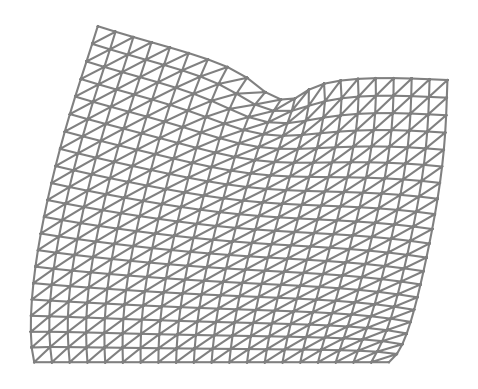

In [ ]:
fe.plot(u[3], Vh, warp=True)

In [46]:
Q(u[4])

/tmp/ipython-input-797914084.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1-np.abs(u[:, top][:, 1::2]).max(axis = -1)


TypeError: unsupported operand type(s) for -: 'int' and 'torch.return_types.max'

In [ ]:
top = 1-fe.dofs(Vh)[:, 1] < 1e-10
def hailstone_position(u):
  if(len(u.shape)==2):
    return 1-np.abs(u[:, top][:, 1::2]).max(axis = -1)
  elif(len(u.shape)==1):
    return hailstone_position(u.reshape(1, -1))[0]
  else:
    raise RuntimeError("u should have either shape (Ns, Nh) or (Nh,).")

In [ ]:
def Q(u):
  return 1.0 - hailstone_position(u)

In [ ]:
u.shape

(200, 882)

In [ ]:
# Since the quantity of interest is a scalar we get n_data
# of them
Qmc = Q(u)

In [ ]:
from scipy.stats import norm
alpha = 0.05

qmean = Qmc.mean()
quncertainty = norm.ppf(1-alpha/2.) * np.sqrt(Qmc.var(ddof=1)/len(Qmc))

qmean, quncertainty

(np.float64(0.2984875702393446), np.float64(0.006998030425827024))

In [ ]:
num2p(quncertainty/qmean)

'2.34%'

<mark>**Exercise 2**</mark></br>
Suppose that we want to improve (lower) this number without a. Access to new data b. Access to the model. As a preliminary step towards the implementation of multi-fidelity Monte Carlo, construct a POD-NN surrogate for the hailstone problem. To do so, use only $N_{\text{train}}=150$ simulations, leaving the rest for later.

What is the average relative $L^2$ error of the surrogate?

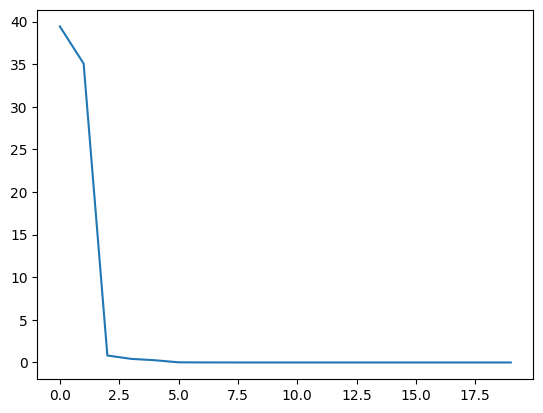

In [78]:
from scipy.linalg import svd
ntrain = 150

# SVD analysis and extraction of the POD basis
# This is explained energy, if we center it we can talk about
# "explained variance"

# Another important part is:
# NEVER GO BELOW THE NUMBER OF PARAMETERS
# This is
from scipy.linalg import svd
X, s, Yt = svd(u[:ntrain].T, full_matrices=False)

n = 10
V = X[:, :4]

plt.plot(s[:20])

# The first singular value essentially recovers the mean
# (we did not normalize the data)
# thus, even if we consider it, we shouldn't really plot itb

In [79]:
# Data compression (solutions -> POD coefficients)
uproj = u @ V @ V.T

/tmp/ipython-input-977219143.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  uproj = u @ V @ V.T


In [80]:
mu, u, uproj, V = dv.tensor(mu, u, uproj, V)

/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (*[ttensor(array, dtype = self.dtype, device = self.device) for array in arrays],)


In [81]:
# Design and training of the reduced network
c = u @ V
c.shape

p = mu.shape[-1]
n = c.shape[-1]

architecture = Dense(p, 20, gelu) + Dense(20, n, None)
phi = DFNN(architecture)

phi.to(dv)
phi.He()
phi.train(mu, c, ntrain = ntrain, nvalid = 50, epochs = 50, loss = mse(euclidean))

phi.freeze()

		Train		Valid		Test
Epoch 50:	1.85e-03	3.26e-03	3.24e-03.

>> ETA: 0.08s.


Training complete. Elapsed time: 4.11 seconds.


In [82]:
# Error assessment
l2 = L2(Vh)
l2.to(dv)
clc()# TODO

upodnn = phi(mu[:ntrain]) @ V.T
num2p(mre(l2)(u[:ntrain], upodnn))

'1.11%'

<mark>**Exercise 3**</mark></br>
Use the POD-NN surrogate to generate $N_0=10^5$ new PDE solutions. Leverage those and the remaining $N_1=50$ full order simulations to approximate the desired expectation with a multi-fidelity estimator. In doing so, provide a pointwise estimate together with a 95\% confidence interval.

Did you manage to reduce uncertainties? If so, by which  factor?

Recall:
Specifically, we let
$$0.9\le \lambda\le 1.1,\quad\quad 0.5\le \nu \le 1.0,\quad\quad \frac{\pi}{4}\le\theta\le\frac{3\pi}{4},\quad\quad 1\le m\le 1.5.$$
uniformly, and set $\boldsymbol{\mu}=[\lambda,\nu,\theta,m]^\top.$

In [85]:
n1 = len(u)-ntrain
n0 = 100000

# Sampling of new n0 parameter values
lambda_par = np.random.uniform(0.9, 1.1, n0).reshape(-1, 1)
nu = np.random.uniform(0.5, 1., n0).reshape(-1, 1)
theta  = np.random.uniform(np.pi/4, 3*np.pi/4, n0).reshape(-1, 1)
m = np.random.uniform(1, 1.5, n0).reshape(-1, 1)

mu_sim = np.concat((lambda_par, nu, theta, m), axis=1)
mu_sim.shape

# Casting to correct type
mu_sim, mu = dv.tensor(mu_sim, mu)

# Evaluation of the ROM (and corresponding QoI) over the n0+n1 parameter values
upodnn_n0 = phi(mu_sim) @ V.T
upodnn_n1 = phi(mu[ntrain:]) @ V.T

/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (*[ttensor(array, dtype = self.dtype, device = self.device) for array in arrays],)


In [87]:
# Multi-fidelity estimate and UQ computation
q_podnn_n1 = Q(u[ntrain:].detach().numpy()) - Q(upodnn_n1.detach().numpy())
q_podnn_n0 = Q(upodnn_n0.detach().numpy())

In [88]:
# Uncertainty reduction
alpha = 0.05

qmean_podnn = q_podnn_n0.mean() + q_podnn_n1.mean()
quncertainty = norm.ppf(1-alpha/2.) * (np.sqrt(q_podnn_n0.var(ddof=1)/n0)) + norm.ppf(1-alpha/2.) * (np.sqrt(q_podnn_n1.var(ddof=1)/n1))

qmean_podnn, quncertainty

(np.float32(0.29995015), np.float64(0.0014295324643025125))

In [91]:
num2p(quncertainty/qmean)

'0.48%'